# Intelligent Patient Risk Assessment  
## Notebook 02 — Advanced Exploratory Data Analysis (EDA)

This notebook performs deep exploratory analysis to understand relationships between clinical features and heart disease risk.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded")

Libraries loaded


In [2]:
from google.colab import files
import io

print("📁 Upload cleaned_data.csv from Notebook-01")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Cleaned dataset loaded")
df.head()

📁 Upload cleaned_data.csv from Notebook-01


Saving cleaned_data.csv to cleaned_data.csv
Cleaned dataset loaded


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,145,136,236,6.36,8.18,51.716583,53.581369,50.796020,57.387241,51.492983
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,30,93,150,2.00,5.63,26.096162,47.946740,23.853485,36.219202,3.984993
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,36,118,195,5.07,7.51,54.830087,42.141104,38.977694,42.898797,21.793300
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,140,139,253,5.28,9.03,60.729521,60.286946,53.579555,52.194082,22.962029
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,160,137,184,12.74,7.20,32.778085,15.279074,18.721942,32.095465,34.296907


In [4]:
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Shape: (97297, 33)
Columns: 33


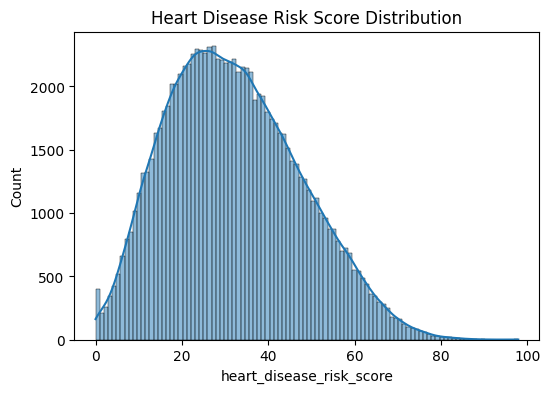

,heart_disease_risk_score
count,97297.000000
mean,32.063255
std,15.412755
min,0.000000
25%,20.389335
50%,30.793098
75%,42.564698
max,97.902483


In [5]:
target_col = "heart_disease_risk_score"

plt.figure(figsize=(6,4))
sns.histplot(df[target_col], kde=True)
plt.title("Heart Disease Risk Score Distribution")
plt.show()

df[target_col].describe()

In [6]:
def risk_category(x):
    if x < 0.33:
        return "Low"
    elif x < 0.66:
        return "Medium"
    else:
        return "High"

df["risk_category"] = df[target_col].apply(risk_category)

print("Risk categories created")
df["risk_category"].value_counts()

Risk categories created


,count
risk_category,
High,96941
Low,306
Medium,50


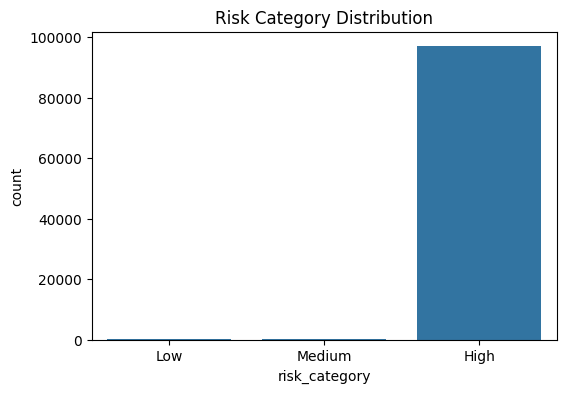

risk_category
High      0.996341
Low       0.003145
Medium    0.000514
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="risk_category", data=df, order=["Low","Medium","High"])
plt.title("Risk Category Distribution")
plt.show()

print(df["risk_category"].value_counts(normalize=True))

### The dataset shows the distribution of patients across different heart disease risk levels.

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# remove target from features
numeric_features = [col for col in numeric_cols if col != target_col]

print("Numeric features:", len(numeric_features))

Numeric features: 26


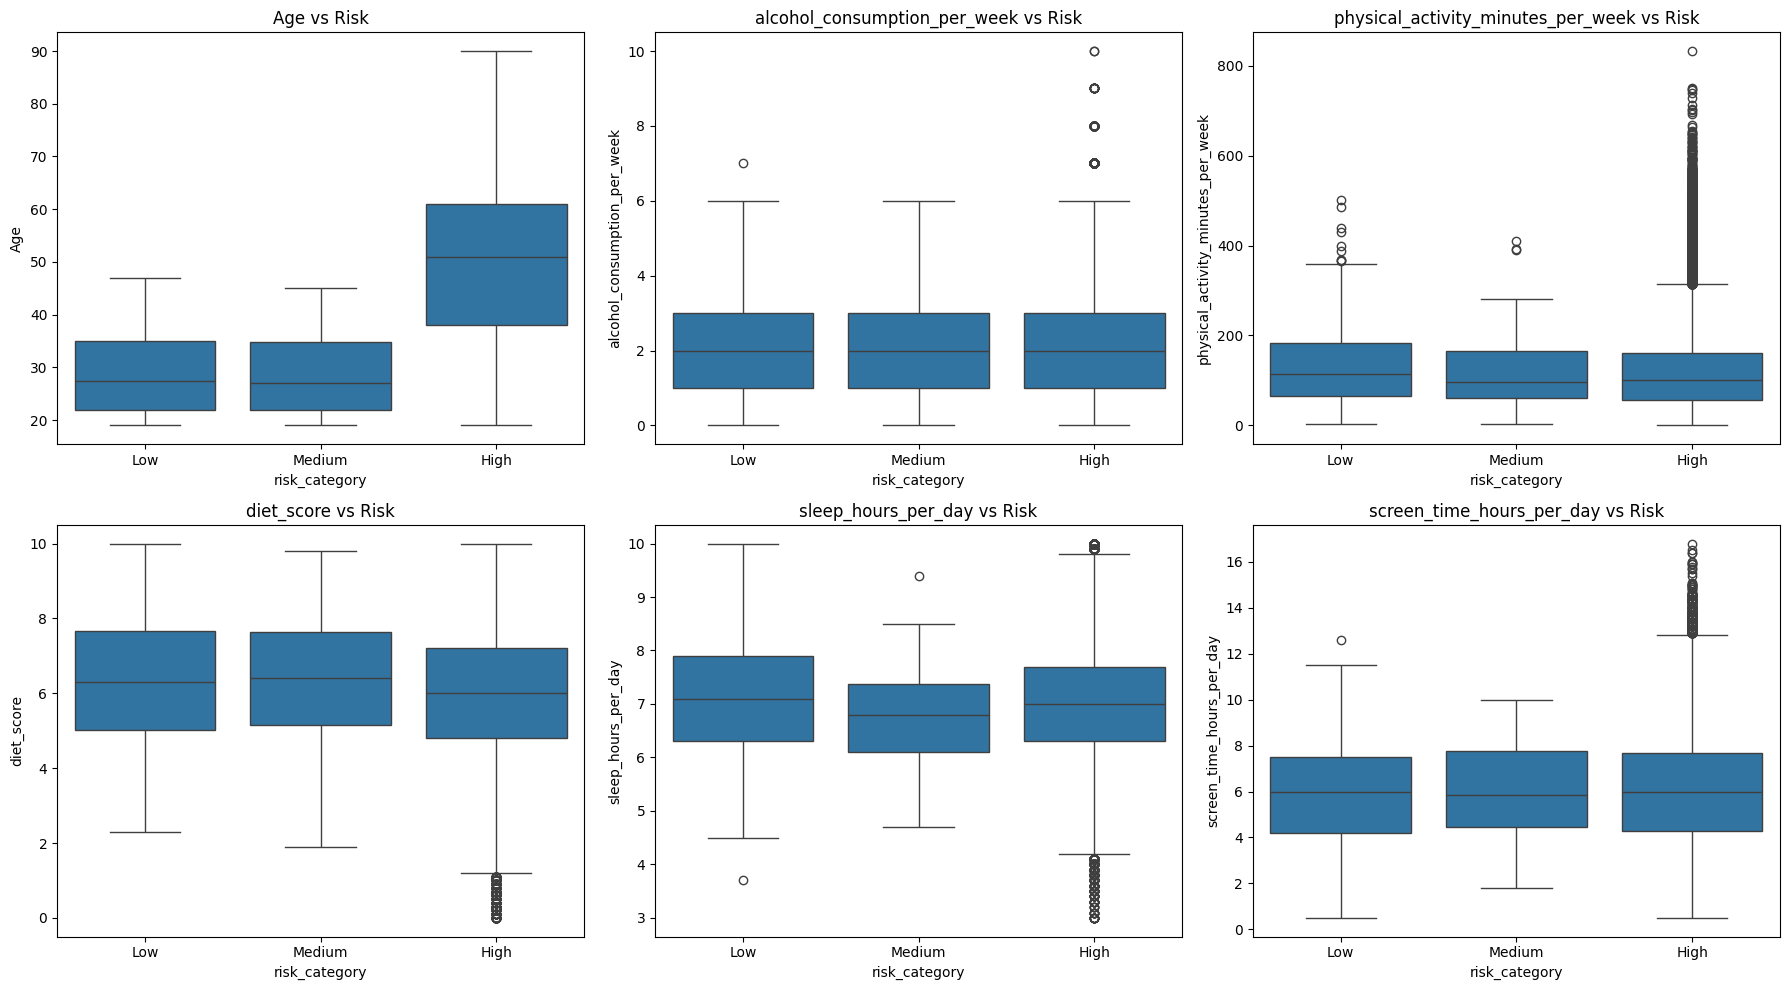

Numerical vs risk analysis done


In [9]:
important_features = numeric_features[:6]

plt.figure(figsize=(18,10))

for i, col in enumerate(important_features, 1):
    plt.subplot(2,3,i)
    sns.boxplot(x="risk_category", y=col, data=df,
                order=["Low","Medium","High"])
    plt.title(f"{col} vs Risk")

plt.tight_layout()
plt.show()

print("Numerical vs risk analysis done")

### Several clinical variables show increasing median values across higher risk categories.

In [10]:
corr_with_target = (
    df[numeric_cols]
    .corr()[target_col]
    .abs()
    .sort_values(ascending=False)
)

display(corr_with_target.head(15))

,heart_disease_risk_score
heart_disease_risk_score,1.000000
hypertension_risk_score,0.799018
Age,0.798682
systolic_bp,0.633569
diabetes_risk_score,0.492923
cholesterol_risk_score,0.471368
ldl_cholesterol,0.450703
cholesterol_total,0.430790
glucose_fasting,0.328287
hba1c,0.304846


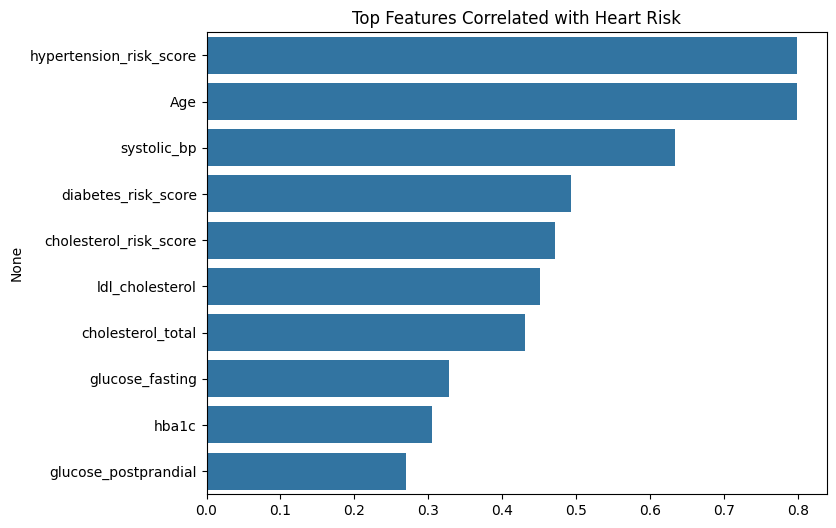

In [11]:
top_corr = corr_with_target[1:11]

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top Features Correlated with Heart Risk")
plt.show()

In [12]:
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# remove risk_category from list
cat_features = [col for col in cat_cols if col != "risk_category"]

print("Categorical features:", cat_features)

Categorical features: ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']


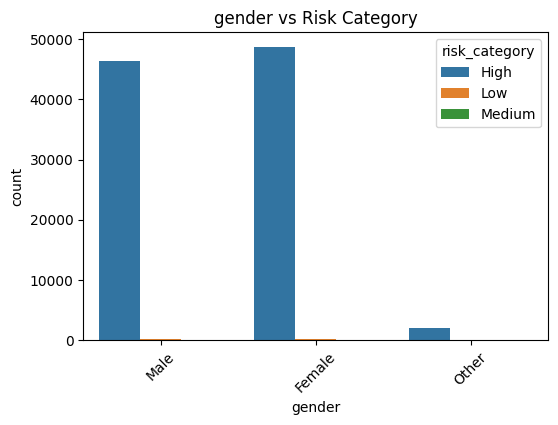

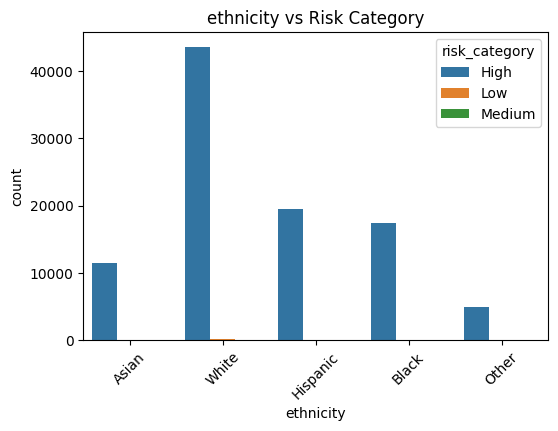

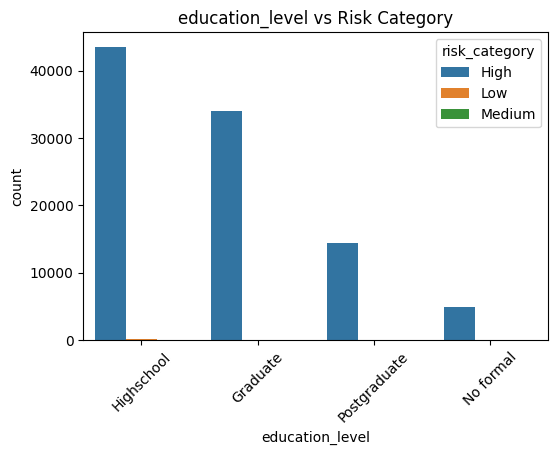

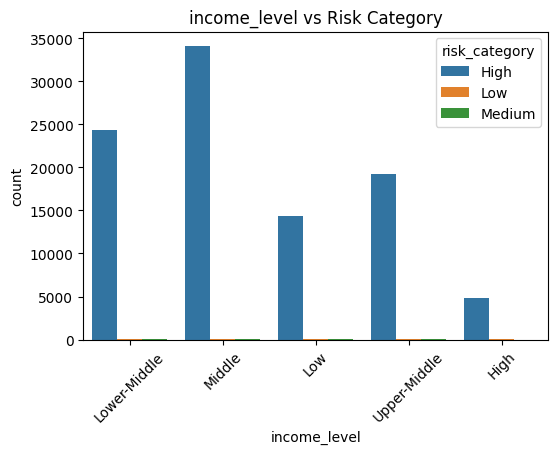

Categorical analysis completed


In [13]:
for col in cat_features[:4]:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="risk_category", data=df)
    plt.title(f"{col} vs Risk Category")
    plt.xticks(rotation=45)
    plt.show()

print("Categorical analysis completed")

### Certain lifestyle and demographic factors show visible variation across risk groups.

## MULTIVARIATE ANALYSIS

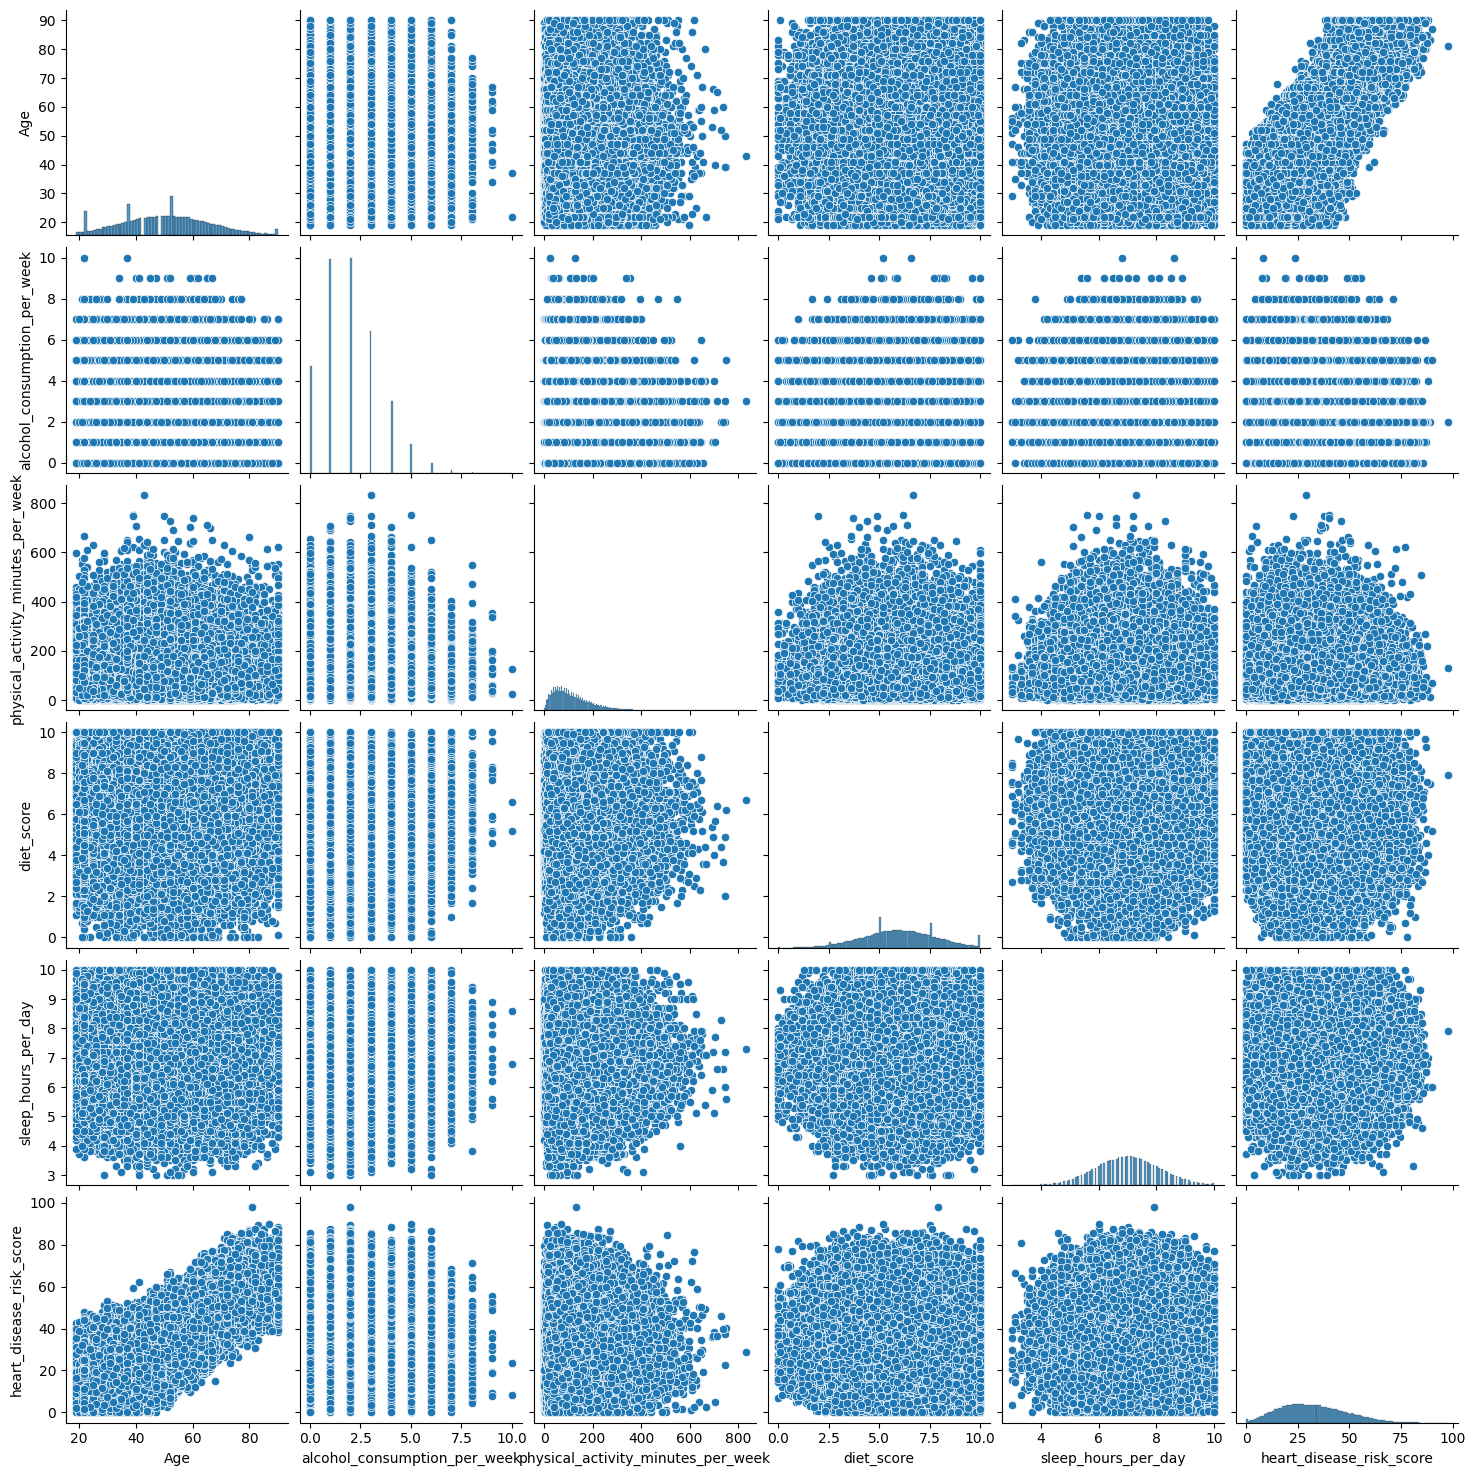

In [14]:
sample_features = numeric_features[:5] + [target_col]

sns.pairplot(df[sample_features])
plt.show()

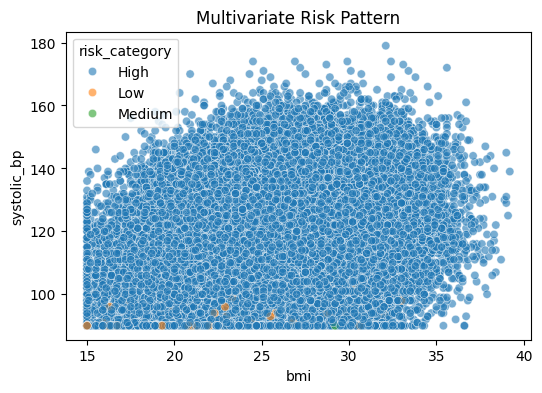

In [16]:
possible_cols = [c for c in df.columns if "bmi" in c or "bp" in c]

if len(possible_cols) >= 2:
    plt.figure(figsize=(6,4))
    sns.scatterplot(
        x=possible_cols[0],
        y=possible_cols[1],
        hue="risk_category",
        data=df,
        alpha=0.6
    )
    plt.title("Multivariate Risk Pattern")
    plt.show()
else:
    print("BMI/BP columns not found — skipping plot")

In [17]:
group_summary = df.groupby("risk_category")[numeric_features[:8]].mean()
display(group_summary)

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history
risk_category,,,,,,,,
High,50.27133,2.004714,118.879071,5.993918,6.997507,5.997349,0.220072,0.251431
Low,28.77451,1.901961,137.323529,6.369608,7.098039,5.888889,0.094771,0.120915
Medium,28.82000,2.300000,130.180000,6.216000,6.774000,6.042000,0.180000,0.040000


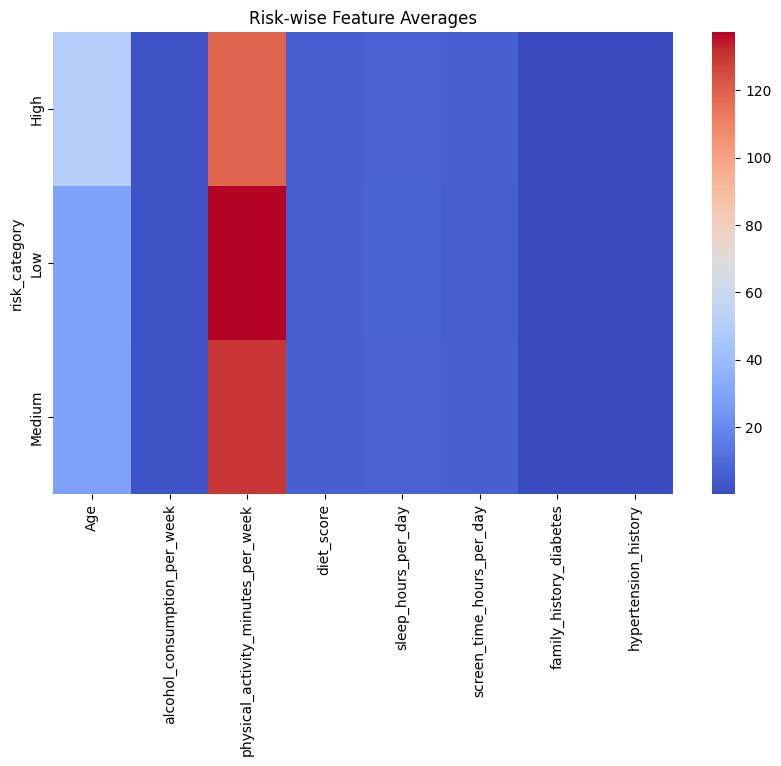

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(group_summary, cmap="coolwarm", annot=False)
plt.title("Risk-wise Feature Averages")
plt.show()

##  Key EDA Insights

- #### Age and cardiovascular indicators show strong association with heart risk.
- #### Certain lifestyle factors contribute to elevated risk levels.
- #### The dataset shows meaningful separation between risk categories.
- #### No severe anomalies were observed after preprocessing.

### These insights guide the feature selection and model development in subsequent notebooks.

## Advanced Feature Intelligence

The following analyses are performed to further understand predictive power, feature redundancy, and class separability to guide model development.

,Feature,Mutual Information
11,systolic_bp,0.006236
23,hypertension_risk_score,0.006220
25,cholesterol_risk_score,0.005627
0,Age,0.005138
14,cholesterol_total,0.004777
16,ldl_cholesterol,0.004732
1,alcohol_consumption_per_week,0.004318
7,hypertension_history,0.004169
6,family_history_diabetes,0.003320
22,diabetes_risk_score,0.003316


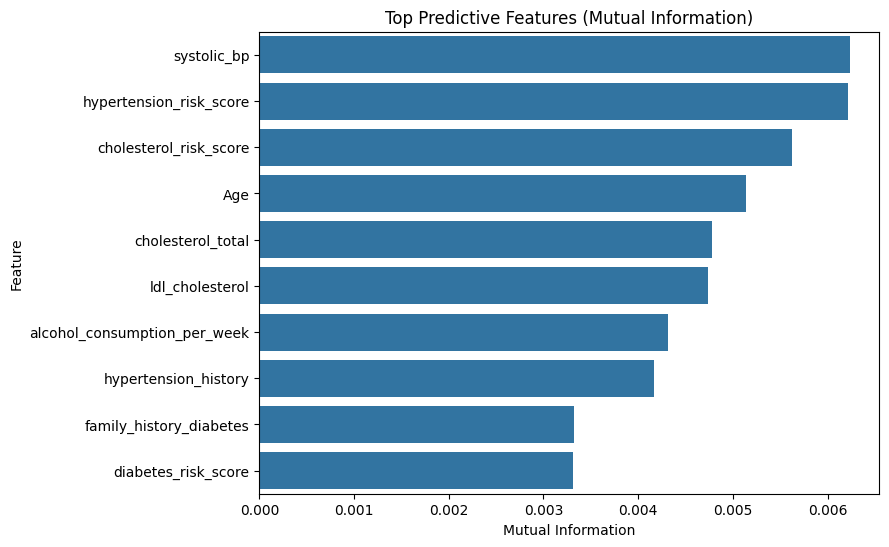

Mutual information analysis completed


In [20]:
from sklearn.feature_selection import mutual_info_classif

# prepare data
X_mi = df[numeric_features]
y_mi = df["risk_category"].map({"Low":0, "Medium":1, "High":2})

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

mi_df = pd.DataFrame({
    "Feature": numeric_features,
    "Mutual Information": mi_scores
}).sort_values(by="Mutual Information", ascending=False)

display(mi_df.head(15))

plt.figure(figsize=(8,6))
sns.barplot(x="Mutual Information", y="Feature", data=mi_df.head(10))
plt.title("Top Predictive Features (Mutual Information)")
plt.show()

print("Mutual information analysis completed")

### Mutual information reveals nonlinear dependencies between clinical variables and heart risk.

In [21]:
corr_matrix = df[numeric_features].corr().abs()

# find highly correlated pairs
high_corr_pairs = []

threshold = 0.85

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

display(high_corr_df)

print("Multicollinearity check completed")

,Feature 1,Feature 2,Correlation
0,ldl_cholesterol,cholesterol_total,0.906133
1,hba1c,glucose_postprandial,0.933174
2,obesity_risk_score,bmi,0.905456
3,cholesterol_risk_score,ldl_cholesterol,0.933756


Multicollinearity check completed


### Highly correlated features may introduce redundancy and will be considered during feature selection.

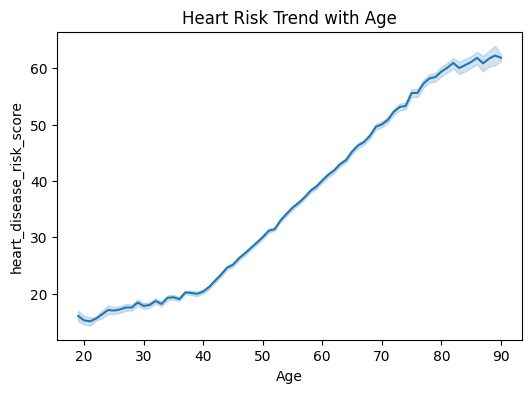

Age-risk trend plotted


In [22]:
age_col = [c for c in df.columns if "age" in c.lower()]

if age_col:
    age_col = age_col[0]

    plt.figure(figsize=(6,4))
    sns.lineplot(
        x=age_col,
        y=target_col,
        data=df
    )
    plt.title("Heart Risk Trend with Age")
    plt.show()

    print("Age-risk trend plotted")
else:
    print("Age column not found")

### Heart disease risk shows an increasing trend with age, aligning with clinical expectations.